In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.datasets import mnist
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from tensorflow.keras.utils import to_categorical

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


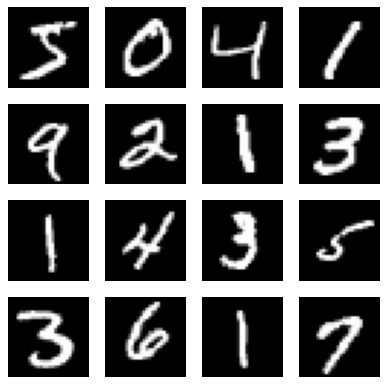

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32"); y_train = y_train.astype("float32")
x_test = x_test.astype("float32"); y_test = y_test.astype("float32")

# Normalization
x_train, x_test = x_train / 255.0, x_test / 255.0

plt.figure(figsize=(6, 6), dpi=80)
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')

In [96]:
# Integer labelings
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(20, activation='relu'))
model.add(Dense(10, activation="softmax"))
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=[SparseCategoricalAccuracy(name="acc")])

model.summary()

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_26 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_53 (Dense)                     │ (None, 20)                  │          15,700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_54 (Dense)                     │ (None, 10)                  │             210 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,910 (62.15 KB)

 Trainable params: 15,910 (62.15 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
h1 = model.fit(x_train, y_train, batch_size=64, epochs=20, validation_split=0.2)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.7497 - loss: 0.8954 - val_acc: 0.9268 - val_loss: 0.2676
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.9256 - loss: 0.2681 - val_acc: 0.9368 - val_loss: 0.2266
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9363 - loss: 0.2232 - val_acc: 0.9434 - val_loss: 0.2029
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9432 - loss: 0.1928 - val_acc: 0.9442 - val_loss: 0.1956
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.9482 - loss: 0.1836 - val_acc: 0.9507 - val_loss: 0.1803
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9544 - loss: 0.1596 - val_acc: 0.9502 - val_loss: 0.1773
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9555 - loss: 0.1527 - val_acc: 0.9495 - val_loss: 0.1727
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.9578 - loss: 0.1438 - val_acc: 0.9517 - val_loss: 0.1689
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - ac

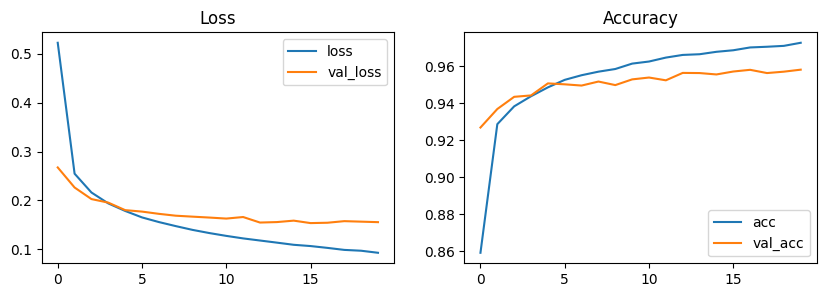

In [73]:
plt.figure(figsize=(10,3))
plt.subplot(121)
plt.title('Loss')
plt.plot(h1.epoch, h1.history['loss'], h1.epoch, h1.history['val_loss'])
plt.legend(['loss','val_loss'])

plt.subplot(122)
plt.title('Accuracy')
plt.plot(h1.epoch, h1.history['acc'], h1.epoch, h1.history['val_acc'])
plt.legend(['acc','val_acc'])

plt.show()

In [74]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9484 - loss: 0.1798


[0.1636187732219696, 0.954800009727478]

In [4]:
# Iris Classification using 1-Hot Labels
y_train_cat = to_categorical(y_train) # convert labels to 1-hot
y_test_cat = to_categorical(y_test)

model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(20, activation='relu'))
model.add(Dense(10, activation="softmax"))
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["acc"])
h2 = model.fit(x_train, y_train_cat, batch_size=64, epochs=20, validation_split=0.2)

C:\Users\WBS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - acc: 0.7578 - loss: 0.8622 - val_acc: 0.9185 - val_loss: 0.2903
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.9191 - loss: 0.2840 - val_acc: 0.9337 - val_loss: 0.2410
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - acc: 0.9311 - loss: 0.2420 - val_acc: 0.9396 - val_loss: 0.2187
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9368 - loss: 0.2210 - val_acc: 0.9419 - val_loss: 0.2080
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9419 - loss: 0.2001 - val_acc: 0.9452 - val_loss: 0.1981
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - acc: 0.9466 - loss: 0.1863 - val_acc: 0.9448 - val_loss: 0.1958
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - acc: 0.9487 - loss: 0.1737 - val_acc: 0.9434 - val_loss: 0.1898
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9516 - loss: 0.1622 - val_acc: 0.9473 - val_loss: 0.1823
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step -

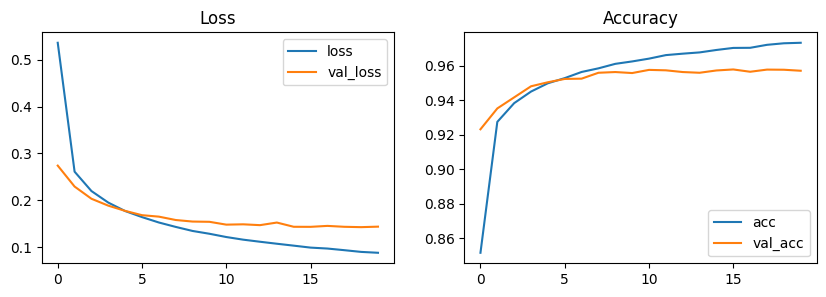

In [76]:
plt.figure(figsize=(10,3))
plt.subplot(121)
plt.title('Loss')
plt.plot(h2.epoch, h2.history['loss'], h2.epoch, h2.history['val_loss'])
plt.legend(['loss','val_loss'])

plt.subplot(122)
plt.title('Accuracy')
plt.plot(h2.epoch, h2.history['acc'], h2.epoch, h2.history['val_acc'])
plt.legend(['acc','val_acc'])

plt.show()

In [77]:
model.summary()
model.evaluate(x_test, y_test_cat)

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_24 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 20)                  │          15,700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 10)                  │             210 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 47,732 (186.46 KB)

 Trainable params: 15,910 (62.15 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 31,822 (124.31 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9562 - loss: 0.1590


[0.140976682305336, 0.9610999822616577]

In [4]:
# CNN model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Input, Flatten

model = Sequential()
model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(32, kernel_size=(2, 2), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(32, kernel_size=(2, 2), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(10, activation="softmax"))

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["acc"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 27, 27, 32)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 12, 12, 32)          │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │          11,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,818 (61.79 KB)

 Trainable params: 15,818 (61.79 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
h3 = model.fit(x_train, y_train_cat, batch_size=64, epochs=20, validation_split=0.2)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - acc: 0.8136 - loss: 0.6736 - val_acc: 0.9697 - val_loss: 0.1055
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - acc: 0.9702 - loss: 0.0991 - val_acc: 0.9765 - val_loss: 0.0816
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - acc: 0.9781 - loss: 0.0700 - val_acc: 0.9787 - val_loss: 0.0706
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - acc: 0.9828 - loss: 0.0578 - val_acc: 0.9803 - val_loss: 0.0637
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - acc: 0.9837 - loss: 0.0520 - val_acc: 0.9802 - val_loss: 0.0661
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - acc: 0.9866 - loss: 0.0436 - val_acc: 0.9820 - val_loss: 0.0577
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - acc: 0.9868 - loss: 0.0436 - val_acc: 0.9840 - val_loss: 0.0551
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - acc: 0.9890 - loss: 0.0328 - val_acc: 0.9829 - val_loss: 0.0579
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 

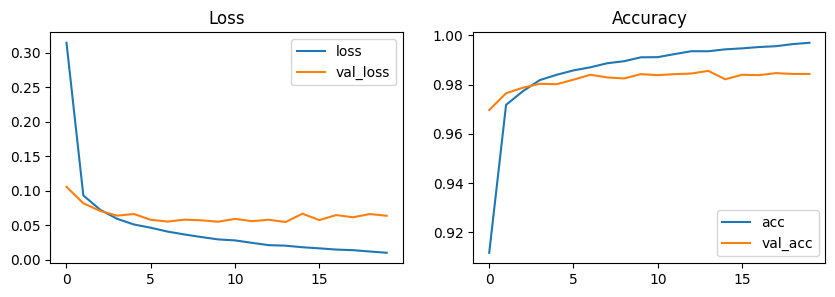

In [62]:
plt.figure(figsize=(10,3))
plt.subplot(121)
plt.title('Loss')
plt.plot(h3.epoch, h3.history['loss'], h3.epoch, h3.history['val_loss'])
plt.legend(['loss','val_loss'])

plt.subplot(122)
plt.title('Accuracy')
plt.plot(h3.epoch, h3.history['acc'], h3.epoch, h3.history['val_acc'])
plt.legend(['acc','val_acc'])

plt.show()

In [63]:
model.evaluate(x_test, y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9828 - loss: 0.0728


[0.05917047709226608, 0.9865000247955322]

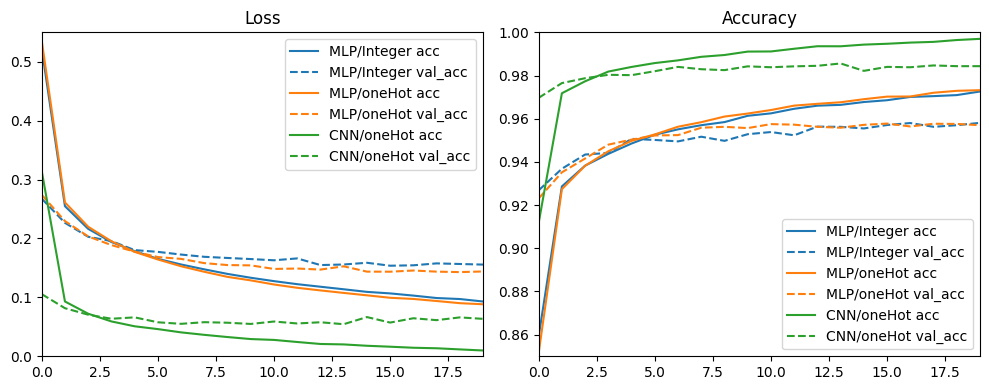

In [94]:
# Compare all
plt.figure(figsize=(10,4))

ylim1, ylim2 = (0.0, 0.55), (0.85, 1.00)
xlim = (0,19)

# ---- Loss ----
plt.subplot(121)
plt.title('Loss')

# h1
l1, = plt.plot(h1.epoch, h1.history['loss'])
plt.plot(h1.epoch, h1.history['val_loss'], linestyle='--', color=l1.get_color())
# h2
l2, = plt.plot(h2.epoch, h2.history['loss'])
plt.plot(h2.epoch, h2.history['val_loss'], linestyle='--', color=l2.get_color())
# h3
l3, = plt.plot(h3.epoch, h3.history['loss'])
plt.plot(h3.epoch, h3.history['val_loss'], linestyle='--', color=l3.get_color())

plt.ylim(ylim1); plt.xlim(xlim)
plt.legend([
    'MLP/Integer acc','MLP/Integer val_acc',
    'MLP/oneHot acc','MLP/oneHot val_acc',
    'CNN/oneHot acc','CNN/oneHot val_acc'
])


# ---- Accuracy ----
plt.subplot(122)
plt.title('Accuracy')

# h1
a1, = plt.plot(h1.epoch, h1.history['acc'])
plt.plot(h1.epoch, h1.history['val_acc'], linestyle='--', color=a1.get_color())
# h2
a2, = plt.plot(h2.epoch, h2.history['acc'])
plt.plot(h2.epoch, h2.history['val_acc'], linestyle='--', color=a2.get_color())
# h3
a3, = plt.plot(h3.epoch, h3.history['acc'])
plt.plot(h3.epoch, h3.history['val_acc'], linestyle='--', color=a3.get_color())

plt.ylim(ylim2); plt.xlim(xlim)
plt.legend([
    'MLP/Integer acc','MLP/Integer val_acc',
    'MLP/oneHot acc','MLP/oneHot val_acc',
    'CNN/oneHot acc','CNN/oneHot val_acc'
])

plt.tight_layout()
plt.show()

In [35]:
# Make CNN overfit
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Input, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
lim = 3200
x_train_low = x_train[:lim,:]
x_test_low = x_train[:lim,:]
y_train_cat_low = to_categorical(y_train)[:lim,:] # convert labels to 1-hot
y_test_cat_low = to_categorical(y_test)[:lim,:]

cb = EarlyStopping(monitor='val_loss', patience=10, min_delta=0.005, restore_best_weights=True)

model = Sequential()
model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(64, kernel_size=(2, 2), activation="relu"))
model.add(Conv2D(64, kernel_size=(2, 2), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(2, 2), activation="relu"))
model.add(Conv2D(64, kernel_size=(2, 2), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(10, activation="softmax"))

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["acc"])

model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_61 (Conv2D)                   │ (None, 27, 27, 64)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_62 (Conv2D)                   │ (None, 26, 26, 64)          │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_36 (MaxPooling2D)      │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_63 (Conv2D)                   │ (None, 12, 12, 64)          │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_64 (Conv2D)                   │ (None, 11, 11, 64)          │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_37 (MaxPooling2D)      │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_18 (Flatten)                 │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 10)                  │          16,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 65,674 (256.54 KB)

 Trainable params: 65,674 (256.54 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
h4 = model.fit(x_train_low, y_train_cat_low, batch_size=64, epochs=50, validation_split=0.2, callbacks=[cb])

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - acc: 0.3649 - loss: 1.8267 - val_acc: 0.8438 - val_loss: 0.5214
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - acc: 0.8790 - loss: 0.4038 - val_acc: 0.9094 - val_loss: 0.3157
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step - acc: 0.9373 - loss: 0.2205 - val_acc: 0.9469 - val_loss: 0.1942
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - acc: 0.9624 - loss: 0.1425 - val_acc: 0.9609 - val_loss: 0.1743
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - acc: 0.9670 - loss: 0.1085 - val_acc: 0.9531 - val_loss: 0.1959
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - acc: 0.9724 - loss: 0.0933 - val_acc: 0.9609 - val_loss: 0.1827
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - acc: 0.9829 - loss: 0.0614 - val_acc: 0.9594 - val_loss: 0.1986
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - acc: 0.9918 - loss: 0.0316 - val_acc: 0.9594 - val_loss: 0.2269
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 

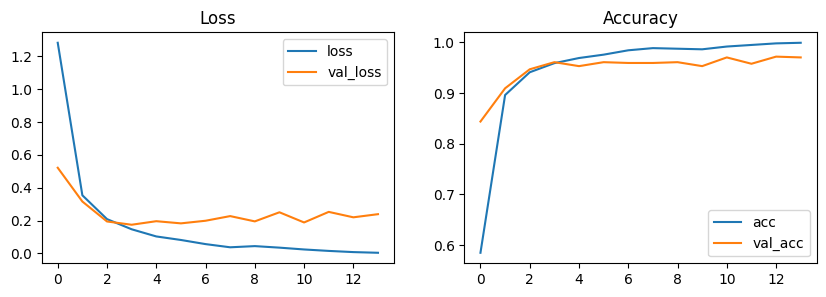

In [32]:
plt.figure(figsize=(10,3))
plt.subplot(121)
plt.title('Loss')
plt.plot(h4.epoch, h4.history['loss'], h4.epoch, h4.history['val_loss'])
plt.legend(['loss','val_loss'])

plt.subplot(122)
plt.title('Accuracy')
plt.plot(h4.epoch, h4.history['acc'], h4.epoch, h4.history['val_acc'])
plt.legend(['acc','val_acc'])

plt.show()

In [39]:
# Add dropout layer
model = Sequential()
model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(64, kernel_size=(2, 2), activation="relu"))
model.add(Conv2D(64, kernel_size=(2, 2), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(2, 2), activation="relu"))
model.add(Conv2D(64, kernel_size=(2, 2), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(10, activation="softmax"))

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["acc"])

model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_69 (Conv2D)                   │ (None, 27, 27, 64)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_70 (Conv2D)                   │ (None, 26, 26, 64)          │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_40 (MaxPooling2D)      │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_71 (Conv2D)                   │ (None, 12, 12, 64)          │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_72 (Conv2D)                   │ (None, 11, 11, 64)          │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_41 (MaxPooling2D)      │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_20 (Flatten)                 │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 10)                  │          16,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 65,674 (256.54 KB)

 Trainable params: 65,674 (256.54 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
h5 = model.fit(x_train_low, y_train_cat_low, batch_size=64, epochs=50, validation_split=0.2, callbacks=[cb])

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 207ms/step - acc: 0.3080 - loss: 1.9790 - val_acc: 0.8516 - val_loss: 0.4788
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - acc: 0.8087 - loss: 0.6054 - val_acc: 0.8969 - val_loss: 0.3392
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - acc: 0.9053 - loss: 0.3393 - val_acc: 0.9266 - val_loss: 0.2448
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - acc: 0.9391 - loss: 0.2387 - val_acc: 0.9484 - val_loss: 0.1609
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - acc: 0.9505 - loss: 0.1729 - val_acc: 0.9438 - val_loss: 0.1613
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 350ms/step - acc: 0.9669 - loss: 0.1282 - val_acc: 0.9547 - val_loss: 0.1801
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - acc: 0.9503 - loss: 0.1485 - val_acc: 0.9594 - val_loss: 0.1449
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - acc: 0.9604 - loss: 0.1272 - val_acc: 0.9688 - val_loss: 0.1380
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - acc: 0

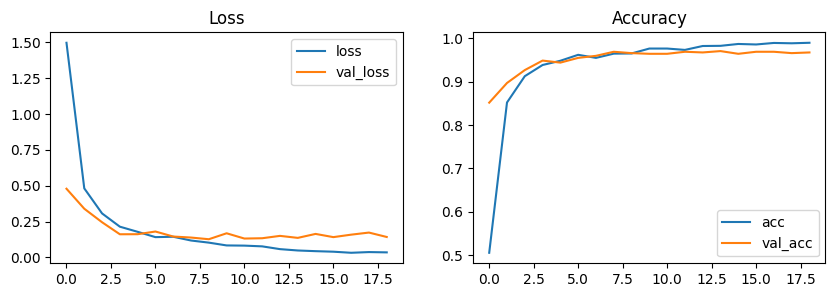

In [41]:
plt.figure(figsize=(10,3))
plt.subplot(121)
plt.title('Loss')
plt.plot(h5.epoch, h5.history['loss'], h5.epoch, h5.history['val_loss'])
plt.legend(['loss','val_loss'])

plt.subplot(122)
plt.title('Accuracy')
plt.plot(h5.epoch, h5.history['acc'], h5.epoch, h5.history['val_acc'])
plt.legend(['acc','val_acc'])

plt.show()

In [15]:
# Add hypertuning to MLP
from tensorflow.keras.optimizers import Adam

def build_model(hp):
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))
    hp_units = hp.Int('units', min_value=5, max_value=50, step=5)
    model.add(Dense(hp_units, activation='relu'))
    model.add(Dense(10, activation="softmax"))
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    adam = Adam(learning_rate=hp_lr)
    model.compile(optimizer=adam,
                  loss="categorical_crossentropy",
                  metrics=["acc"])

    return model

In [18]:
import keras_tuner as kt
# objective is the objective to select the best model. max_trials specifies the number of models to try.
tuner = kt.RandomSearch(build_model,
                        objective='val_loss',
                        max_trials=10,
                        overwrite=True)
# start the search
tuner.search(x_train[:10000,:], y_train_cat[:10000,:], 
             epochs=10,
             validation_split=0.2)
# get the best trained model
best_model = tuner.get_best_models()[0]
# get the best hyperparameter (HyperParameter object)
best_hp = tuner.get_best_hyperparameters()[0]
# print a summary of the results
tuner.results_summary()

Trial 10 Complete [00h 00m 29s]
val_loss: 0.24527490139007568

Best val_loss So Far: 0.24527490139007568
Total elapsed time: 00h 06m 03s
Results summary
Results in .\untitled_project
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 09 summary
Hyperparameters:
units: 45
learning_rate: 0.01
Score: 0.24527490139007568

Trial 07 summary
Hyperparameters:
units: 35
learning_rate: 0.001
Score: 0.25748690962791443

Trial 04 summary
Hyperparameters:
units: 25
learning_rate: 0.01
Score: 0.32605645060539246

Trial 06 summary
Hyperparameters:
units: 10
learning_rate: 0.001
Score: 0.34504660964012146

Trial 01 summary
Hyperparameters:
units: 30
learning_rate: 0.0001
Score: 0.4232931435108185

Trial 08 summary
Hyperparameters:
units: 25
learning_rate: 0.0001
Score: 0.4655541777610779

Trial 03 summary
Hyperparameters:
units: 20
learning_rate: 0.0001
Score: 0.4833533763885498

Trial 02 summary
Hyperparameters:
units: 15
learning_rate: 0.0001
Score: 0.5105089545249939

Trial 0